 # Importing relevant libraries

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Loading dataset

In [95]:
dataset = pd.read_csv('Titanic-Dataset.csv')

# Getting basic dataset overview

In [96]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [97]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [98]:
# This shows number of rows and columns: (rows, columns)
dataset.shape

(891, 12)

In [99]:
dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Visualisation and Analysis

#### How Many People Survived/Didn't?

0    549
1    342
Name: Survived, dtype: int64

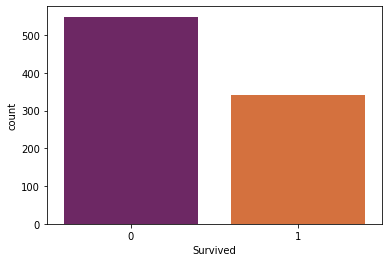

In [100]:
sns.countplot(x = 'Survived', data = dataset, palette = 'inferno')

# 0 = Did not survive, 1 = Survived
dataset['Survived'].value_counts()

#### How many males and female passengers were there?

male      577
female    314
Name: Sex, dtype: int64

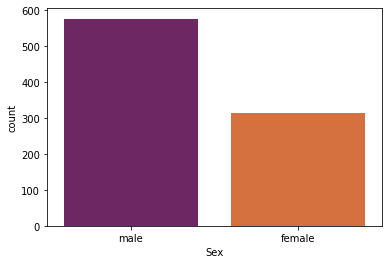

In [101]:
sns.countplot(x = 'Sex', data = dataset, palette = 'inferno')
dataset['Sex'].value_counts()

#### Survival Rate by Gender

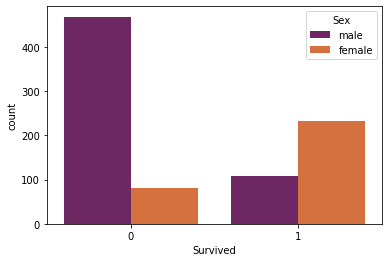

In [102]:
sns.countplot(x = 'Survived', hue = 'Sex', data = dataset, palette = 'inferno')

#### Number of Passengers in Each Class      

3    491
1    216
2    184
Name: Pclass, dtype: int64

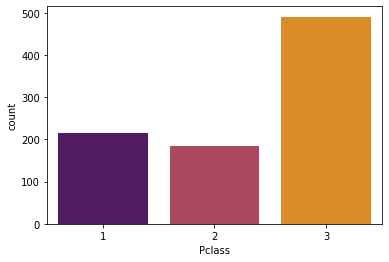

In [103]:
sns.countplot(x = 'Pclass', data = dataset, palette ='inferno')
dataset['Pclass'].value_counts()

# 1 = 1st Class, 2 = 2nd Class, 3 = 3rd Class

#### Gender Distribution in Different Classes

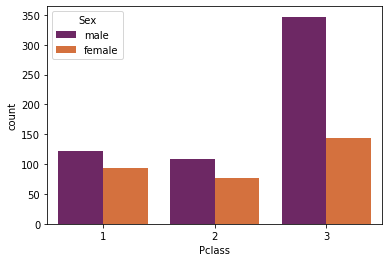

In [104]:
sns.countplot(x = 'Pclass', hue ='Sex', data = dataset, palette = 'inferno')

#### Influence of Class on Survival Chances

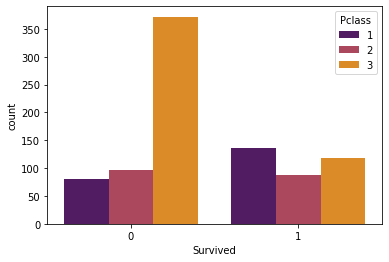

In [105]:
sns.countplot(x = 'Survived', hue ='Pclass', data = dataset, palette = 'inferno')

#### Correlation Between Point of Embarkment and Survival?

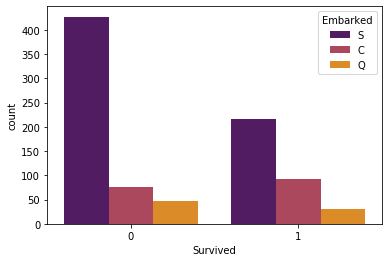

In [106]:
sns.countplot(x = 'Survived', hue ='Embarked', data = dataset, palette = 'inferno')

#### Relationship Between Embarkment and Class

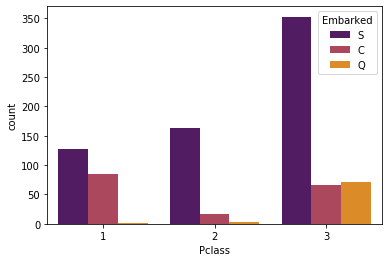

In [107]:
sns.countplot(x = 'Pclass', hue ='Embarked', data = dataset, palette = 'inferno')

#### Passenger Age Distribution

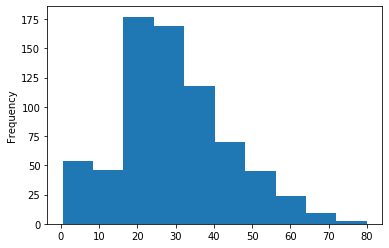

In [108]:
dataset['Age'].plot.hist()

#### Age Distribution Among Classes

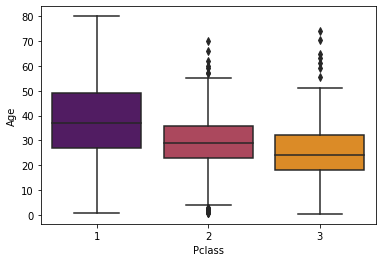

In [109]:
sns.boxplot(x = 'Pclass', y = 'Age', data = dataset, palette = 'inferno')

#### Age Range of Those Who Survived/Didn't

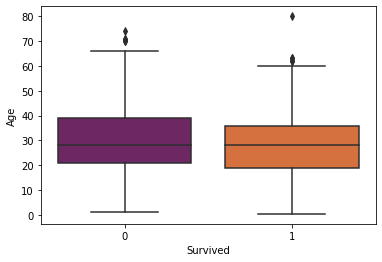

In [110]:
sns.boxplot(x = 'Survived', y = 'Age', data = dataset, palette = 'inferno')

#### Passenger Fare Distribution

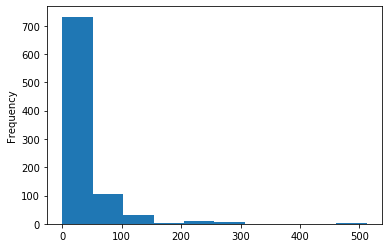

In [111]:
dataset['Fare'].plot.hist()

#### Correlation Between Fare Paid and Class

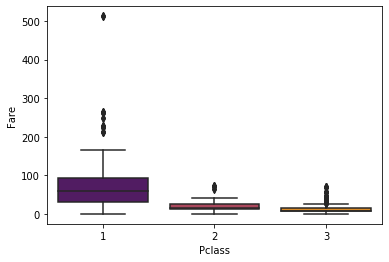

In [112]:
sns.boxplot(x = 'Pclass', y = 'Fare', data = dataset, palette = 'inferno')

#### Correlation Between Fare Range and Survival

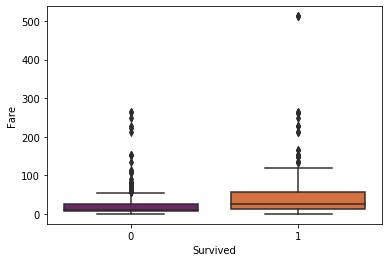

In [113]:
sns.boxplot(x = 'Survived', y = 'Fare', data = dataset, palette = 'inferno')

#### Family Size Frequency (Parent and Child)

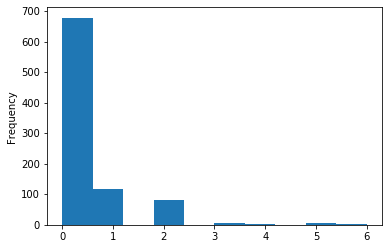

In [114]:
dataset['Parch'].plot.hist()

#### Family Size Frequency (Siblings and Spouse) 

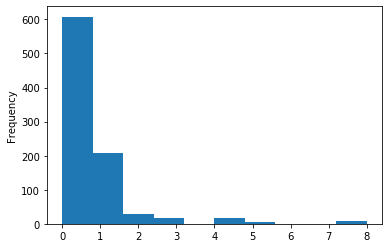

In [115]:
dataset['SibSp'].plot.hist()

# Data Wrangling

#### Checking For Missing Values

In [116]:
missing_values = dataset.isnull().sum()
print (missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


#### Heatmap Illustrating the Distribution of Missing Values

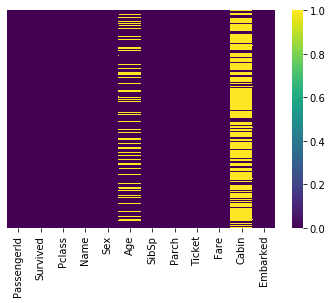

In [117]:
sns.heatmap(dataset.isnull(), yticklabels = False, cmap = 'viridis')

In [118]:
# Filling the missing age cells with mean

mean_age = dataset['Age'].mean()
dataset['Age'] = dataset['Age'].fillna(mean_age)

In [119]:
# Dropping Cabin column

dataset.drop('Cabin', axis = 1, inplace = True)

In [120]:
# Dropping Irrelevant Columns

dataset.drop('Name', axis = 1, inplace = True)
dataset.drop('Ticket', axis = 1, inplace = True)

In [121]:
dataset.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       2
dtype: int64

In [122]:
# Dropping rows with missing values

dataset.dropna(axis = 0, how = 'any')

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.000000,1,0,7.2500,S
1,2,1,1,female,38.000000,1,0,71.2833,C
2,3,1,3,female,26.000000,0,0,7.9250,S
3,4,1,1,female,35.000000,1,0,53.1000,S
4,5,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0,13.0000,S
887,888,1,1,female,19.000000,0,0,30.0000,S
888,889,0,3,female,29.699118,1,2,23.4500,S
889,890,1,1,male,26.000000,0,0,30.0000,C


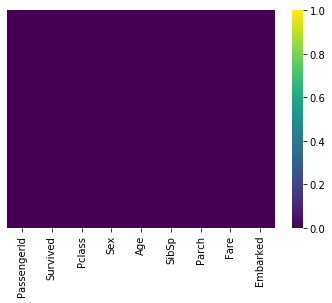

In [123]:
# Confirming full resolution of missing values

sns.heatmap(dataset.isnull(), yticklabels = False, cmap = 'viridis')

# Encoding Categorical Variables

In [124]:
sex = pd.get_dummies(dataset['Sex'], drop_first = True)
sex.head()

,male
0,1
1,0
2,0
3,0
4,1


In [125]:
embarked = pd.get_dummies(dataset['Embarked'], drop_first = True)
embarked.head()

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [126]:
pclass = pd.get_dummies(dataset['Pclass'], drop_first = True)
pclass.head()

,2,3
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1


In [129]:
# Dropping Sex, Embarked and Pclass as they have been converted

dataset.drop ('Sex', axis = 1, inplace = True)
dataset.drop ('Embarked', axis = 1, inplace = True)
dataset.drop ('Pclass', axis = 1, inplace = True)

In [131]:
final_data = pd.concat([dataset, sex, pclass, embarked], axis = 1)
final_data.head()

,PassengerId,Survived,Age,SibSp,Parch,Fare,male,2,3,Q,S
0,1,0,22.0,1,0,7.2500,1,0,1,0,1
1,2,1,38.0,1,0,71.2833,0,0,0,0,0
2,3,1,26.0,0,0,7.9250,0,0,1,0,1
3,4,1,35.0,1,0,53.1000,0,0,0,0,1
4,5,0,35.0,0,0,8.0500,1,0,1,0,1


# Exporting the final result

In [132]:
final_data.to_csv('cleaned.csv', index = False)